# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [6]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [7]:
def plot_audio_seg(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()


def plot_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)

    ax = plt.gca()
    if len(plot_dets)>0:
        plot_dets = plot_dets[(plot_dets['start_time']>=start)&(plot_dets['end_time']<=(start+duration))]
        for i, row in plot_dets.iterrows():
            rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                            (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                            linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
            ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 256e3/fs, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 6), 
               labels=np.linspace(0, duration, 6, dtype=plot_xtype), rotation=0)
    plt.xlabel("Time (s)")
    plt.twinx(ax=ax)
    plt.yticks(ticks=np.linspace(0, 256e3/fs, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.ylim(0, 256e3/fs)

    plt.show()

In [8]:
def convert_nabatdf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] =  (df['peak_time_ms']-50)/1000
    raven_df['End Time (s)'] = (df['peak_time_ms']-40)/1000
    raven_df['Low Freq (Hz)'] = df['peak_freq_hz']-2000
    raven_df['High Freq (Hz)'] = df['peak_freq_hz']+2000
    raven_df['prediction'] = df['prediction']
    raven_df['score'] = df['score']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_nabatdf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = (df['peak_time_ms']-50)/1000
    bd2_df['end_time'] = (df['peak_time_ms']-40)/1000
    bd2_df['low_freq'] = df['peak_freq_hz']-2000
    bd2_df['high_freq'] = df['peak_freq_hz']+2000
    bd2_df['prediction'] = df['prediction']
    bd2_df['score'] = df['score']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_kaleidoscopedf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] = df['OFFSET']
    raven_df['End Time (s)'] = df['OFFSET'] + df['DURATION']
    raven_df['Low Freq (Hz)'] = df['Fmin']
    raven_df['High Freq (Hz)'] = df['Fmax']
    raven_df['input_file'] = df['IN FILE']
    raven_df['input_dir'] = df['INDIR']
    raven_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        raven_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        raven_df['TOP1MATCH'] = df['TOP1MATCH']
    raven_df['TOP1DIST'] = df['TOP1DIST']
    raven_df['TOP2MATCH'] = df['TOP2MATCH']
    raven_df['TOP2DIST'] = df['TOP2DIST']
    raven_df['TOP3MATCH'] = df['TOP3MATCH']
    raven_df['TOP3DIST'] = df['TOP3DIST']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_kaleidoscopedf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = df['OFFSET']
    bd2_df['end_time'] = df['OFFSET'] + df['DURATION']
    bd2_df['low_freq'] = df['Fmin']
    bd2_df['high_freq'] = df['Fmax']
    bd2_df['input_file'] = df['IN FILE']
    bd2_df['input_dir'] = df['INDIR']
    bd2_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        bd2_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        bd2_df['TOP1MATCH'] = df['TOP1MATCH']
    bd2_df['TOP1DIST'] = df['TOP1DIST']
    bd2_df['TOP2MATCH'] = df['TOP2MATCH']
    bd2_df['TOP2DIST'] = df['TOP2DIST']
    bd2_df['TOP3MATCH'] = df['TOP3MATCH']
    bd2_df['TOP3DIST'] = df['TOP3DIST']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_raventxtdf_to_bd2df(raventxt_df):
    bd2_human_df = raventxt_df[::2].copy()
    bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Manually-Verified Phonic Group':'freq_group'}, inplace=True)
    bd2_human_df.sort_values('start_time', inplace=True)
    
    return bd2_human_df

In [9]:
wav_filename = '20220826_070000'
site = 'Central'
plot_file = Path(f'../../Documents/mila-human-wav-txt/{wav_filename}.WAV')

In [10]:
raventxt_human_df = pd.read_csv(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK_with_groups.txt', sep='\t')
bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
bd2_human_df['freq_group'] = bd2_human_df['freq_group'].str.strip()
bd2_human_df.reset_index(inplace=True, drop=True)
bd2_human_df

,start_time,end_time,low_freq,high_freq,Delta Time (s),Annotation,detection_confidence,input_file,freq_group
0,1.729564,1.737108,44070.175,51087.719,0.0075,AK_echolocation,NaN,NaN,HF
1,3.770500,3.777100,45234.000,54096.000,0.0066,Echolocation,0.512,20220826_070000.WAV,HF
2,3.911402,3.918947,43903.720,56927.790,0.0075,AK_echolocation,NaN,NaN,HF
3,4.043419,4.050209,44281.690,58478.873,0.0068,AK_echolocation,NaN,NaN,HF
4,4.161126,4.170934,43903.720,56507.659,0.0098,AK_echolocation,NaN,NaN,HF
...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,Echolocation,0.587,20220826_070000.WAV,HF
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,Echolocation,0.591,20220826_070000.WAV,HF
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,Echolocation,0.544,20220826_070000.WAV,HF
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,Echolocation,0.566,20220826_070000.WAV,HF


In [11]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]

        machine_det_start_in_human_det_bounds = ((machine_det['start_time']>=human_det['start_time'])&(machine_det['start_time']<=human_det['end_time']))
        machine_det_end_in_human_det_bounds = ((machine_det['end_time']>=human_det['start_time'])&(machine_det['end_time']<=human_det['end_time']))
        human_det_start_in_machine_det_bounds = ((human_det['start_time']>=machine_det['start_time'])&(human_det['start_time']<=machine_det['end_time']))
        human_det_end_in_machine_det_bounds = ((human_det['end_time']>=machine_det['start_time'])&(human_det['end_time']<=machine_det['end_time']))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_det['low_freq']>=human_det['low_freq'])&(machine_det['low_freq']<=human_det['high_freq']))
        machine_det_high_in_human_det_bounds = ((machine_det['high_freq']>=human_det['low_freq'])&(machine_det['high_freq']<=human_det['high_freq']))
        human_det_low_in_machine_det_bounds = ((human_det['low_freq']>=machine_det['low_freq'])&(human_det['low_freq']<=machine_det['high_freq']))
        human_det_high_in_machine_det_bounds = ((human_det['high_freq']>=machine_det['low_freq'])&(human_det['high_freq']<=machine_det['high_freq']))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        if len(human_df) < 100:
            print(f'HI:{human_ind}, MI:{machine_ind}, TP:{true_positives}, FP:{false_positives}, FN:{false_negatives}, TN:{true_negatives}')
            print(f'Dets match time: {machine_det_time_matches_human_time}, Dets match freq: {machine_det_freq_matches_human_time}')

        if (machine_detection_corresponds_to_human):
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_det['end_time']<=human_det['start_time'])&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_det['start_time']<=human_det['start_time'])&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_det['start_time']>human_det['end_time'])&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_det['start_time']>human_det['start_time'])&(~machine_det_freq_matches_human_time)

            if len(human_df) < 100:
                print(f'FP same group: {false_positive_same_group_before_human_det}, FP diff group: {false_positive_diff_group_before_human_det}')
                print(f'FN same group: {false_negative_same_group_before_human_det}, FN diff group: {false_negative_diff_group_before_human_det}')
            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))

    return {'true_positives':true_positives, 'false_positives':false_positives, 'false_negatives':false_negatives, 'true_negatives':true_negatives}

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

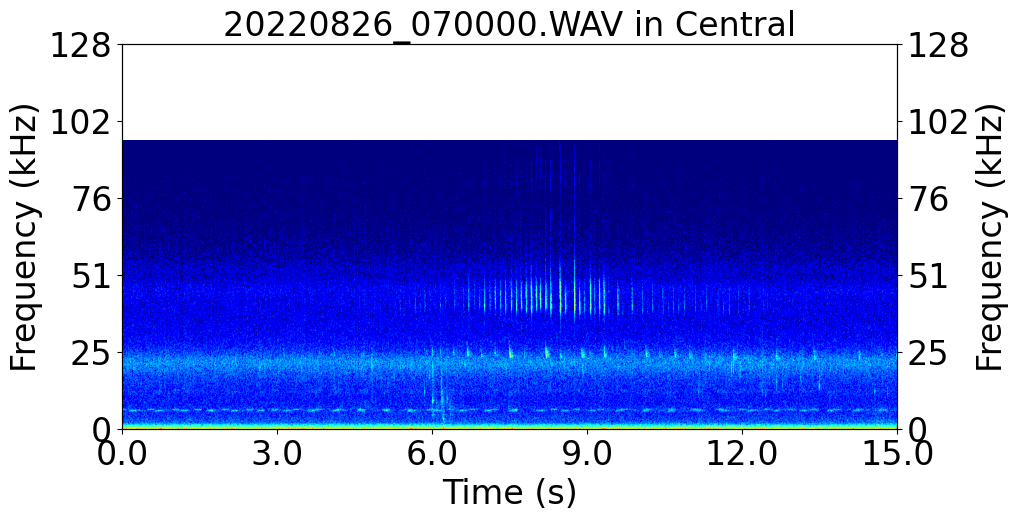

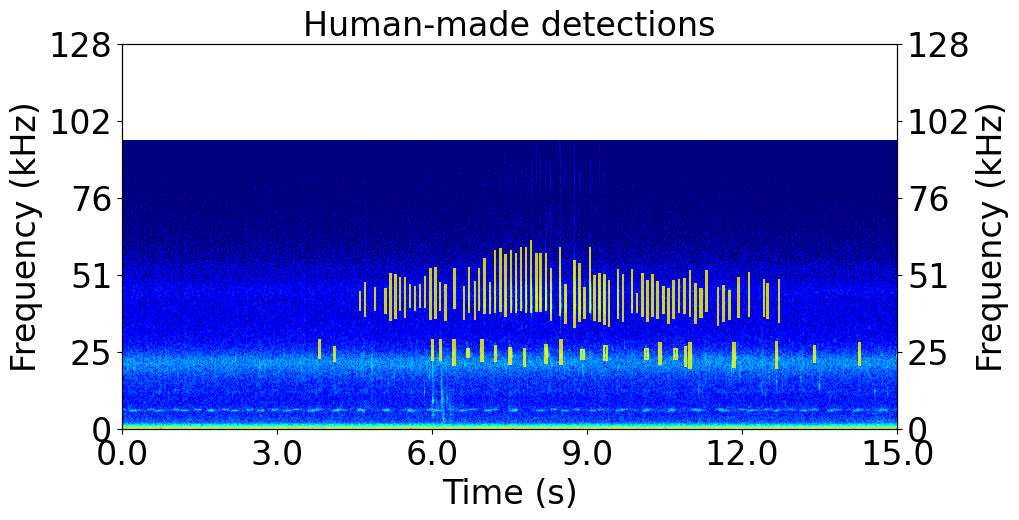

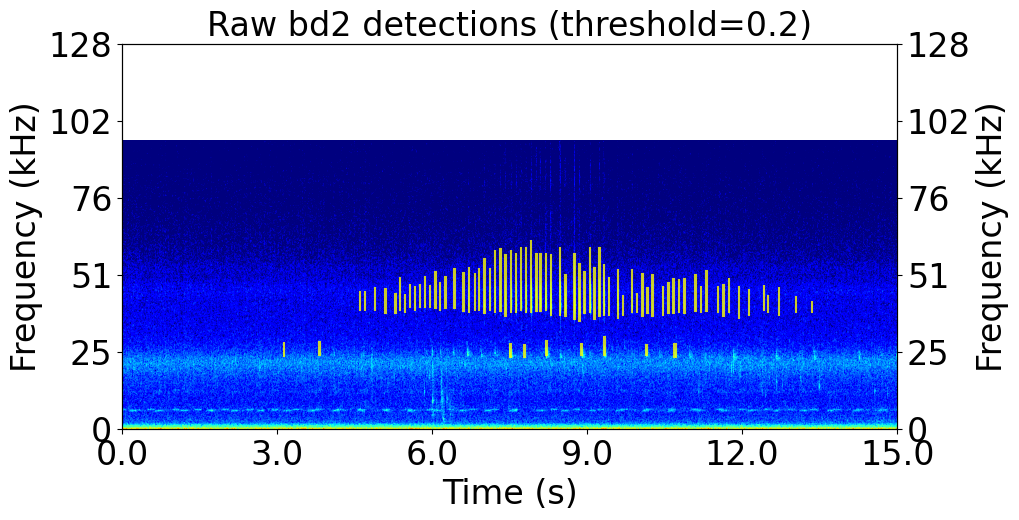

In [ ]:
# Below we filter our detections dataframe to only get the detections corresponding to the above audio file
audio_file = sf.SoundFile(plot_file)
fs = audio_file.samplerate
start = 360
duration = 15
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmin = -60
vmax = 0
audio_features = dict()
audio_features['file_path'] = Path(plot_file)
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax


spec_features['plot_title'] = f"{audio_features['file_path'].name} in {site}"
plot_dets_over_audio(audio_features, spec_features, pd.DataFrame())
spec_features['plot_title'] = f"Human-made detections"
plot_dets_over_audio(audio_features, spec_features, bd2_human_df)

plot_thresh = 0.20
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00

ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")

save_dir = Path(f'20241231__detection_threshold_sweep_results')
filepath = save_dir / save_loc
batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df_selected = batdetect2_df[batdetect2_df['det_prob']>=plot_thresh].copy()
spec_features['plot_title'] = f"Raw bd2 detections (threshold={plot_thresh})"
plot_dets_over_audio(audio_features, spec_features, batdetect2_df_selected)

In [13]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [14]:
def gather_evaluation_results_between_bd2_and_human(bd2_human_df, batdetect2_df_thresh):
    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df_thresh)
    row = pd.DataFrame([file_batdetect2_cf])
    row.insert(0, 'num_human_annotations', [len(bd2_human_df)])
    row.insert(0, 'num_bd2_detections', [len(batdetect2_df_thresh)])
    denom_precision = (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_positives'])
    denom_recall = (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_negatives'])
    if (denom_precision>0):
        precision = file_batdetect2_cf['true_positives'] / denom_precision
    else:
        precision = np.NaN
    if (denom_recall>0):
        recall = file_batdetect2_cf['true_positives'] / denom_recall
    else:
        recall = np.NaN
    row['precision'] = precision
    row['recall'] = recall

    return row

In [15]:
batdetect2_eval = pd.DataFrame()
for file_key in file_keys:
    print(file_key)
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}.WAV')

    raventxt_human_df = pd.read_csv(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK_with_groups.txt', sep='\t')
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df.reset_index(inplace=True, drop=True)

    save_dir = Path(f'20241231__detection_threshold_sweep_results')
    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")
    filepath = save_dir / save_loc
    batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)

    increment = 0.01
    thresholds = np.arange(0.0, 1.0+increment, increment)
    for i, thresh in enumerate(thresholds):
        print(round(thresh,2))
        batdetect2_df_thresh = batdetect2_df[batdetect2_df['det_prob']>=round(thresh,2)].copy()
        row = gather_evaluation_results_between_bd2_and_human(bd2_human_df, batdetect2_df_thresh)
        row.insert(0, 'detection_threshold', [round(thresh,2)])
        row['input_file_name'] = f'{wav_filename}.WAV'
        row['site_name'] = SITE_NAMES[site]
        batdetect2_eval = pd.concat([batdetect2_eval, row])

20220730_053000
0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99
1.0
20220826_070000
0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96

In [16]:
batdetect2_eval = batdetect2_eval.reset_index(drop=True)
batdetect2_eval

,detection_threshold,num_bd2_detections,num_human_annotations,true_positives,false_positives,false_negatives,true_negatives,precision,recall,input_file_name,site_name
0,0.00,86847,863,824,86023,39,0,0.009488,0.954809,20220730_053000.WAV,Carp Pond
1,0.01,86847,863,824,86023,39,0,0.009488,0.954809,20220730_053000.WAV,Carp Pond
2,0.02,84848,863,824,84024,39,0,0.009711,0.954809,20220730_053000.WAV,Carp Pond
3,0.03,10911,863,836,10075,27,0,0.076620,0.968714,20220730_053000.WAV,Carp Pond
4,0.04,4258,863,824,3434,39,0,0.193518,0.954809,20220730_053000.WAV,Carp Pond
...,...,...,...,...,...,...,...,...,...,...,...
399,0.96,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage
400,0.97,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage
401,0.98,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage
402,0.99,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage


In [17]:
batdetect2_eval.to_csv(save_dir / '20241231__bd2_eval_results_per_thresh_and_file.csv')

In [18]:
batdetect2_eval = pd.read_csv(save_dir / '20241231__bd2_eval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval

,detection_threshold,num_bd2_detections,num_human_annotations,true_positives,false_positives,false_negatives,true_negatives,precision,recall,input_file_name,site_name
0,0.00,86847,863,824,86023,39,0,0.009488,0.954809,20220730_053000.WAV,Carp Pond
1,0.01,86847,863,824,86023,39,0,0.009488,0.954809,20220730_053000.WAV,Carp Pond
2,0.02,84848,863,824,84024,39,0,0.009711,0.954809,20220730_053000.WAV,Carp Pond
3,0.03,10911,863,836,10075,27,0,0.076620,0.968714,20220730_053000.WAV,Carp Pond
4,0.04,4258,863,824,3434,39,0,0.193518,0.954809,20220730_053000.WAV,Carp Pond
...,...,...,...,...,...,...,...,...,...,...,...
399,0.96,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage
400,0.97,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage
401,0.98,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage
402,0.99,0,171,0,0,171,0,NaN,0.000000,20220829_090000.WAV,Foliage


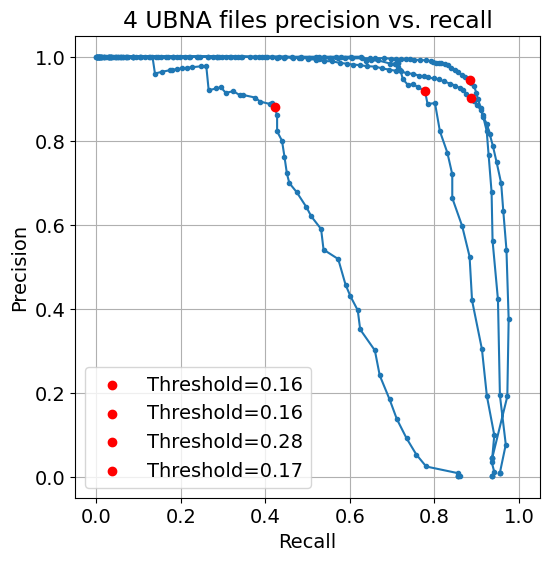

In [19]:
plt.figure(figsize=(6,6))
plt.rcParams.update({'font.size':14})
plt.title(f'4 UBNA files precision vs. recall')
precisions_per_thresh = batdetect2_eval['precision']
recalls_per_thresh = batdetect2_eval['recall']
plt.plot(recalls_per_thresh, precisions_per_thresh, marker='.')
for file in batdetect2_eval['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval[batdetect2_eval['input_file_name']==file].copy()
    file_precisions = batdetect2_eval_file['precision']
    file_recalls = batdetect2_eval_file['recall']
    common_max = (file_precisions * file_recalls).argmax()
    plt.scatter(file_recalls.iloc[common_max], file_precisions.iloc[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
plt.grid(which='both')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

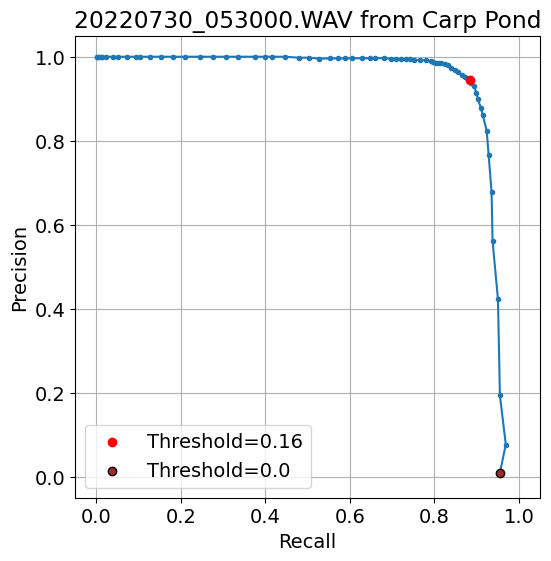

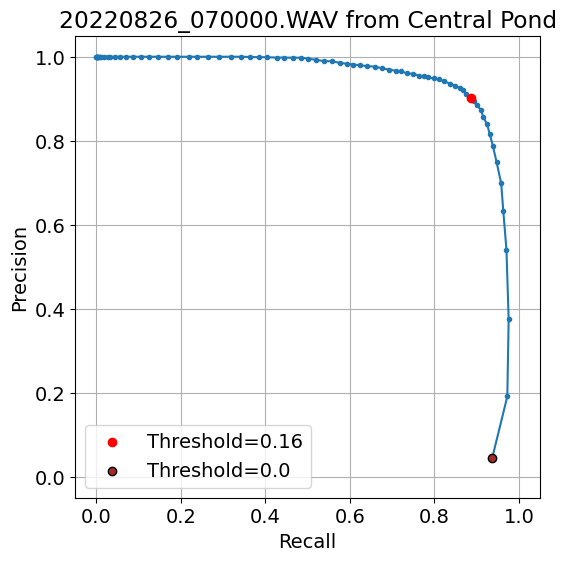

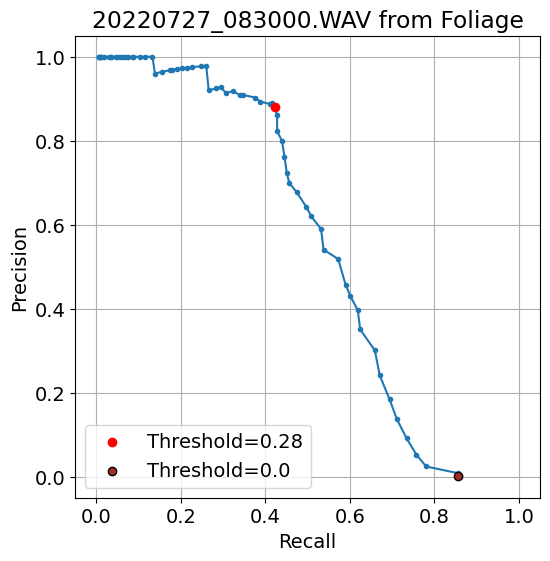

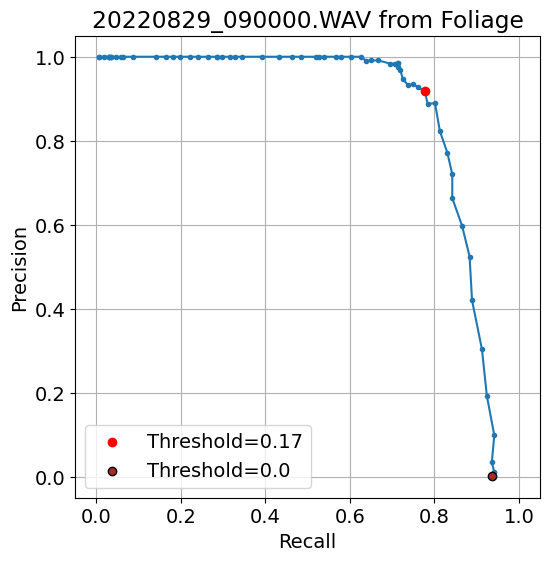

In [20]:
for file in batdetect2_eval['input_file_name'].unique():

    file_precision = batdetect2_eval[batdetect2_eval['input_file_name']==file].set_index('detection_threshold')['precision']
    file_recall = batdetect2_eval[batdetect2_eval['input_file_name']==file].set_index('detection_threshold')['recall']

    plt.figure(figsize=(6,6))
    plt.rcParams.update({'font.size':14})
    plt.title(f'{file} from {SITE_NAMES[file_sites[Path(file).stem]]}')
    precisions_per_thresh = file_precision
    recalls_per_thresh = file_recall
    plt.plot(recalls_per_thresh, precisions_per_thresh, marker='.')
    common_max = (precisions_per_thresh * recalls_per_thresh).argmax()
    plt.scatter(recalls_per_thresh.iloc[common_max], precisions_per_thresh.iloc[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
    spec_thresh = thresholds[0]
    plt.scatter(recalls_per_thresh[spec_thresh], precisions_per_thresh[spec_thresh],
                facecolor='brown', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
    plt.grid(which='both')
    plt.xlim(-0.05,1.05)
    plt.ylim(-0.05,1.05)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='lower left')
    plt.show()

In [35]:
sum_of_files_tp = batdetect2_eval.groupby('detection_threshold', group_keys=True).sum(numeric_only=True)['true_positives']
sum_of_files_fp = batdetect2_eval.groupby('detection_threshold', group_keys=True).sum(numeric_only=True)['false_positives']
sum_of_files_fn = batdetect2_eval.groupby('detection_threshold', group_keys=True).sum(numeric_only=True)['false_negatives']
sum_of_files_tn = batdetect2_eval.groupby('detection_threshold', group_keys=True).sum(numeric_only=True)['true_negatives']

In [39]:
sum_of_files_precision = (sum_of_files_tp / (sum_of_files_tp + sum_of_files_fp))
sum_of_files_recall = (sum_of_files_tp / (sum_of_files_tp + sum_of_files_fn))

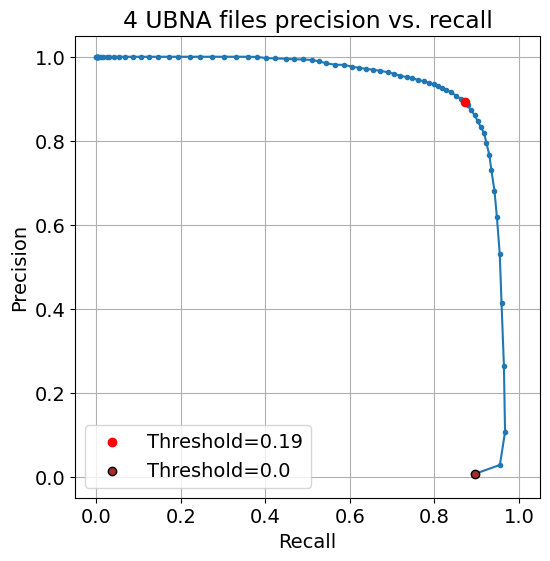

In [44]:
plt.figure(figsize=(6,6))
plt.rcParams.update({'font.size':14})
plt.title(f'4 UBNA files precision vs. recall')
precisions_per_thresh = sum_of_files_precision
recalls_per_thresh = sum_of_files_recall
plt.plot(recalls_per_thresh, precisions_per_thresh, marker='.')
common_max = (precisions_per_thresh * recalls_per_thresh).argmax()
plt.scatter(recalls_per_thresh.iloc[common_max], precisions_per_thresh.iloc[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
spec_thresh = thresholds[0]
plt.scatter(recalls_per_thresh[spec_thresh], precisions_per_thresh[spec_thresh],
            facecolor='brown', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
plt.grid(which='both')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()